In [8]:
import pandas as pd
from abc import ABC, abstractmethod
from dataclasses import dataclass, asdict
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, roc_auc_score

In [2]:
df= pd.read_csv(r"E:\Dowloads\blinkit_dataset.csv")

In [3]:
df

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,...,is_organic,packaging_type,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status
0,1,Tata Organic Grocery 300,Grocery,Tata,199.78,25,149.84,4.5,146,37,...,True,Can,750,212,15,73,2023-11-27,2024-06-26,NaN,On-Time
1,2,Mother Dairy Lite Dairy 275,Dairy,Mother Dairy,44.32,30,31.02,4.0,264,36,...,False,Jar,1000,17,24,25,2024-08-07,2024-08-24,NaN,Delayed
2,3,P&G Classic Personal 439,Personal Care,P&G,501.13,0,501.13,3.7,69,17,...,True,Jar,1000,1463,25,100,2024-03-03,2028-03-05,FreeDelivery,On-Time
3,4,Dettol Fresh Household 771,Household,Dettol,627.17,0,627.17,3.9,103,23,...,True,Bottle,200,1143,18,15,2024-08-07,2027-09-24,NaN,On-Time
4,5,Minute Maid Daily Beverages 264,Beverages,Minute Maid,101.69,15,86.44,4.3,422,10,...,True,Can,300,363,30,6,2024-07-04,2025-07-02,NaN,On-Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12995,12996,Minute Maid Classic Beverages 396,Beverages,Minute Maid,219.17,15,186.29,4.8,450,30,...,False,Pouch,300,482,28,73,2025-01-16,2026-05-13,NaN,On-Time
12996,12997,FreshFarm Organic Fruits 225,Fruits & Vegetables,FreshFarm,348.21,5,330.80,4.5,115,25,...,True,Box,1000,13,19,35,2024-01-11,2024-01-24,Cashback,On-Time
12997,12998,FreshFarm Original Fruits 349,Fruits & Vegetables,FreshFarm,178.86,10,160.97,4.8,199,19,...,True,Bottle,1000,3,20,34,2025-08-08,2025-08-11,NaN,On-Time
12998,12999,Lizol Lite Household 792,Household,Lizol,435.70,5,413.91,3.4,114,18,...,False,Bottle,500,403,24,17,2023-11-11,2024-12-18,NaN,On-Time


In [4]:
df.head()

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,...,is_organic,packaging_type,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status
0,1,Tata Organic Grocery 300,Grocery,Tata,199.78,25,149.84,4.5,146,37,...,True,Can,750,212,15,73,2023-11-27,2024-06-26,NaN,On-Time
1,2,Mother Dairy Lite Dairy 275,Dairy,Mother Dairy,44.32,30,31.02,4.0,264,36,...,False,Jar,1000,17,24,25,2024-08-07,2024-08-24,NaN,Delayed
2,3,P&G Classic Personal 439,Personal Care,P&G,501.13,0,501.13,3.7,69,17,...,True,Jar,1000,1463,25,100,2024-03-03,2028-03-05,FreeDelivery,On-Time
3,4,Dettol Fresh Household 771,Household,Dettol,627.17,0,627.17,3.9,103,23,...,True,Bottle,200,1143,18,15,2024-08-07,2027-09-24,NaN,On-Time
4,5,Minute Maid Daily Beverages 264,Beverages,Minute Maid,101.69,15,86.44,4.3,422,10,...,True,Can,300,363,30,6,2024-07-04,2025-07-02,NaN,On-Time


In [5]:
df.isnull().sum()

product_id              0
product_name            0
category                0
brand                   0
price                   0
discount_pct            0
final_price             0
rating                  0
num_reviews             0
delivery_time_min       0
city                    0
seller                  0
stock                   0
sold_quantity           0
profit_margin_pct       0
is_organic              0
packaging_type          0
weight_g                0
shelf_life_days         0
reorder_level           0
demand_index            0
date_added              0
expiry_date             0
offer_type           6544
delivery_status         0
dtype: int64

In [6]:
df['offer_type'] = df['offer_type'].fillna('No Offer')

In [7]:
df.head()

,product_id,product_name,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,...,is_organic,packaging_type,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status
0,1,Tata Organic Grocery 300,Grocery,Tata,199.78,25,149.84,4.5,146,37,...,True,Can,750,212,15,73,2023-11-27,2024-06-26,No Offer,On-Time
1,2,Mother Dairy Lite Dairy 275,Dairy,Mother Dairy,44.32,30,31.02,4.0,264,36,...,False,Jar,1000,17,24,25,2024-08-07,2024-08-24,No Offer,Delayed
2,3,P&G Classic Personal 439,Personal Care,P&G,501.13,0,501.13,3.7,69,17,...,True,Jar,1000,1463,25,100,2024-03-03,2028-03-05,FreeDelivery,On-Time
3,4,Dettol Fresh Household 771,Household,Dettol,627.17,0,627.17,3.9,103,23,...,True,Bottle,200,1143,18,15,2024-08-07,2027-09-24,No Offer,On-Time
4,5,Minute Maid Daily Beverages 264,Beverages,Minute Maid,101.69,15,86.44,4.3,422,10,...,True,Can,300,363,30,6,2024-07-04,2025-07-02,No Offer,On-Time


In [9]:
#p1  Pricing simulator + Delivery delay model--

# WHY pricing isn't ML — price barely moves sales:
print(df[["final_price", "discount_pct"]].corrwith(df["sold_quantity"]).round(3))
# WHY delivery & sales ARE model-able — real signal exists:
print("demand_index vs sold_quantity:", round(df["demand_index"].corr(df["sold_quantity"]), 3))


final_price     0.002
discount_pct    0.010
dtype: float64
demand_index vs sold_quantity: 0.914


In [10]:
# ---- abstract base: a what-if engine ----
class BaseSimulator(ABC):
    @abstractmethod
    def run(self, **levers): ...
    @abstractmethod
    def summary(self) -> str: ...

@dataclass
class PricingResult:
    price_change: float; units: float; revenue: float; profit: float; margin_pct: float

class PricingSimulator(BaseSimulator):
    """Constant-elasticity pricing what-if (assumption-driven, NOT ML)."""
    def __init__(self, data, elasticity=-1.5):
        self._data = data
        self.elasticity = elasticity
    def _economics(self):
        bp = self._data["final_price"].to_numpy(float)
        bq = self._data["sold_quantity"].to_numpy(float)
        cost = bp * (1 - self._data["profit_margin_pct"].to_numpy(float) / 100)
        return bp, bq, cost
    def run(self, price_change=0.0):
        bp, bq, cost = self._economics()
        r = 1 - price_change / 100              # price_change>0 = discount, <0 = markup
        price, qty = bp * r, bq * (r ** self.elasticity)
        rev = float((price * qty).sum()); prof = float(((price - cost) * qty).sum())
        return PricingResult(price_change, float(qty.sum()), rev, prof,
                             prof/rev*100 if rev > 0 else 0.0)
    def sweep(self, lo=-25, hi=50):
        return pd.DataFrame([asdict(self.run(p)) for p in range(lo, hi + 1)])
    def optimal(self):
        s = self.sweep(); return PricingResult(**s.loc[s["profit"].idxmax()].to_dict())
    def summary(self):
        b, o = self.run(0), self.optimal()
        return (f"[Pricing] elasticity {self.elasticity:+.1f} | today Rs{b.profit:,.0f} "
                f"-> max at {o.price_change:+.0f}% (Rs{o.profit:,.0f})")

# ---- abstract base: a supervised ML model (template method pattern) ----
class BaseMLModel(ABC):
    def __init__(self, data):
        self._data = data; self._pipe = None; self.metrics = {}
    @abstractmethod
    def _columns(self): ...      # -> (numeric_cols, categorical_cols, target)
    @abstractmethod
    def _estimator(self): ...    # -> an unfitted sklearn estimator
    @abstractmethod
    def _score(self, yt, yp): ...
    @abstractmethod
    def summary(self): ...
    def _make_pipeline(self, num, cat):
        pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat)],
                                remainder="passthrough")
        return Pipeline([("pre", pre), ("model", self._estimator())])
    def fit(self):
        num, cat, target = self._columns()
        X, y = self._data[num + cat], self._data[target]
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
        self._pipe = self._make_pipeline(num, cat).fit(Xtr, ytr)
        self.metrics = self._score(yte, self._pipe.predict(Xte))
        self._Xte, self._yte = Xte, yte
        return self

class DeliveryDelayModel(BaseMLModel):
    """Logistic regression: P(order is delayed | delivery time)."""
    def _columns(self):
        self._data = self._data.assign(
            is_delayed=(self._data["delivery_status"] == "Delayed").astype(int))
        return ["delivery_time_min"], [], "is_delayed"
    def _estimator(self): return LogisticRegression(max_iter=1000)
    def _score(self, yt, yp): return {"accuracy": accuracy_score(yt, yp)}
    def fit(self):
        super().fit()
        self.metrics["roc_auc"] = roc_auc_score(self._yte, self._pipe.predict_proba(self._Xte)[:, 1])
        return self
    def predict(self, t):
        return float(self._pipe.predict_proba(pd.DataFrame({"delivery_time_min": [float(t)]}))[0, 1])
    def summary(self):
        return (f"[Delivery] LogReg | acc {self.metrics['accuracy']:.3f}, "
                f"AUC {self.metrics['roc_auc']:.3f} | P(delay@30)={self.predict(30)*100:.0f}%")

# quick try:
print(PricingSimulator(df[df.category == "Grocery"], elasticity=-2.0).summary())
print(DeliveryDelayModel(df).fit().summary())

[Pricing] elasticity -2.0 | today Rs14,585,560 -> max at -25% (Rs19,445,142)
[Delivery] LogReg | acc 0.787, AUC 0.687 | P(delay@30)=21%


In [11]:
# P2 — Sales predictor using ML regression

class SalesPredictor(BaseMLModel):
    """Regression for units sold, with model comparison + honesty ablation."""
    NUM = ["demand_index","price","final_price","discount_pct","rating","num_reviews",
           "delivery_time_min","profit_margin_pct","weight_g","shelf_life_days","stock","reorder_level"]
    CAT = ["category","brand","city","seller","packaging_type","is_organic","offer_type"]
    def __init__(self, data, estimator=None):
        super().__init__(data)
        self._chosen = estimator if estimator is not None else GradientBoostingRegressor(random_state=42)
    def _columns(self): return self.NUM, self.CAT, "sold_quantity"
    def _estimator(self): return self._chosen
    def _score(self, yt, yp): return {"r2": r2_score(yt, yp), "mae": mean_absolute_error(yt, yp)}
    def compare_models(self):
        cands = {"LinearRegression": LinearRegression(),
                 "RandomForest": RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1),
                 "GradientBoosting": GradientBoostingRegressor(random_state=42)}
        rows = [{"model": n, **SalesPredictor(self._data, e).fit().metrics} for n, e in cands.items()]
        return pd.DataFrame(rows).sort_values("r2", ascending=False).reset_index(drop=True)
    def ablation(self):
        num_wo = [c for c in self.NUM if c != "demand_index"]
        X, y = self._data[num_wo + self.CAT], self._data["sold_quantity"]
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
        pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), self.CAT)], remainder="passthrough")
        pipe = Pipeline([("pre", pre), ("m", GradientBoostingRegressor(random_state=42))]).fit(Xtr, ytr)
        return {"r2_with_demand_index": round(self.metrics["r2"], 3),
                "r2_without_demand_index": round(r2_score(yte, pipe.predict(Xte)), 3)}
    def feature_importance(self, top=8):
        names = self._pipe.named_steps["pre"].get_feature_names_out()
        imps = self._pipe.named_steps["model"].feature_importances_
        agg = {}
        for n, i in zip(names, imps):
            raw = n.split("__", 1)[1] if "__" in n else n
            base = raw if raw in self.NUM else next((c for c in self.CAT if raw.startswith(c + "_")), raw)
            agg[base] = agg.get(base, 0.0) + i
        return (pd.DataFrame({"feature": list(agg), "importance": list(agg.values())})
                .sort_values("importance", ascending=False).head(top).reset_index(drop=True))
    def predict(self, **overrides):
        d = {c: float(self._data[c].median()) for c in self.NUM}
        for c in self.CAT: d[c] = self._data[c].mode().iloc[0]
        d.update(overrides)
        return float(self._pipe.predict(pd.DataFrame([d])[self.NUM + self.CAT])[0])
    def summary(self):
        return f"[Sales] {type(self._chosen).__name__} | R2 {self.metrics['r2']:.3f}, MAE {self.metrics['mae']:.0f}"

# quick try:
sp = SalesPredictor(df).fit()
print(sp.compare_models().to_string(index=False))
print("Ablation:", sp.ablation())
print(sp.feature_importance(5).to_string(index=False))

           model       r2       mae
GradientBoosting 0.885593 34.609188
    RandomForest 0.880840 35.435901
LinearRegression 0.860018 38.867796
Ablation: {'r2_with_demand_index': 0.886, 'r2_without_demand_index': -0.003}
     feature  importance
demand_index    0.973955
      rating    0.020359
       price    0.000722
 num_reviews    0.000660
       brand    0.000614


In [12]:
#P4 — Segmentation + facade (using the OOP capstone)
class ProductSegmenter:
    """KMeans clustering — group products by price/rating/demand behaviour."""
    FEATURES = ["final_price","rating","num_reviews","sold_quantity","demand_index","profit_margin_pct"]
    def __init__(self, data, k=4):
        self._data = data; self.k = k; self._pipe = None
    def fit(self):
        self._pipe = Pipeline([("scale", StandardScaler()),
                               ("km", KMeans(n_clusters=self.k, n_init=10, random_state=42))]).fit(self._data[self.FEATURES])
        self._labels = self._pipe.named_steps["km"].labels_
        return self
    def profile(self):
        d = self._data[self.FEATURES].copy(); d["segment"] = self._labels
        return d.groupby("segment").mean().round(1)
    def summary(self):
        sizes = pd.Series(self._labels).value_counts().sort_index().to_dict()
        return f"[Segments] KMeans k={self.k} | sizes {sizes}"

class BlinkitSimulator:
    """Facade: composes the data, simulator, and all ML models into one object."""
    def __init__(self, data):
        self._df = data.copy(); self._df["offer_type"] = self._df["offer_type"].fillna("None")
        self.delivery = DeliveryDelayModel(self._df).fit()
        self.sales    = SalesPredictor(self._df).fit()
        self.segments = ProductSegmenter(self._df).fit()
    def pricing(self, category=None, elasticity=-1.5):
        data = self._df[self._df["category"] == category] if category else self._df
        return PricingSimulator(data, elasticity)
    def report(self):                       # polymorphism: same .summary() call on every part
        print(self.pricing().summary())
        for m in (self.delivery, self.sales, self.segments):
            print(m.summary())

# run the whole thing:
sim = BlinkitSimulator(df)
sim.report()
sim.segments.profile()

[Pricing] elasticity -1.5 | today Rs115,152,653 -> max at -25% (Rs173,454,073)
[Delivery] LogReg | acc 0.787, AUC 0.687 | P(delay@30)=21%
[Sales] GradientBoostingRegressor | R2 0.886, MAE 35
[Segments] KMeans k=4 | sizes {0: 2837, 1: 1706, 2: 4845, 3: 3612}


,final_price,rating,num_reviews,sold_quantity,demand_index,profit_margin_pct
segment,,,,,,
0,168.7,4.2,457.7,99.6,31.4,22.4
1,592.3,4.2,175.8,125.6,36.0,22.1
2,182.2,4.2,169.6,83.5,27.0,23.2
3,209.7,4.2,247.8,334.9,78.2,22.4


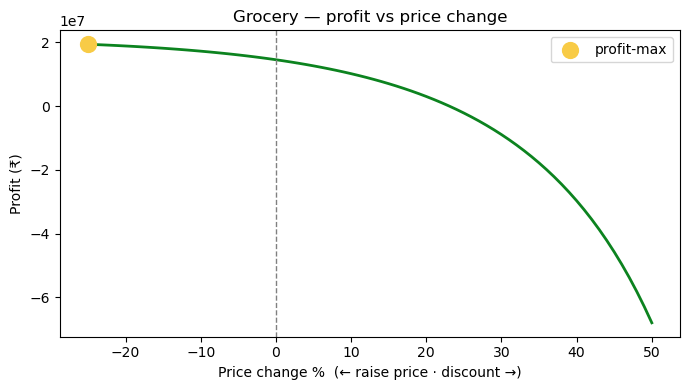

In [13]:
import matplotlib.pyplot as plt

# PLOT 1 — Pricing: profit curve with the profit-max point
pricer = sim.pricing("Grocery", elasticity=-2.0)
sweep, opt = pricer.sweep(), pricer.optimal()
plt.figure(figsize=(7, 4))
plt.plot(sweep["price_change"], sweep["profit"], color="#0C831F", lw=2)
plt.axvline(0, ls="--", color="grey", lw=1)
plt.scatter([opt.price_change], [opt.profit], color="#F8CB46", s=130, zorder=5, label="profit-max")
plt.xlabel("Price change %  (← raise price · discount →)"); plt.ylabel("Profit (₹)")
plt.title("Grocery — profit vs price change"); plt.legend(); plt.tight_layout(); plt.show()

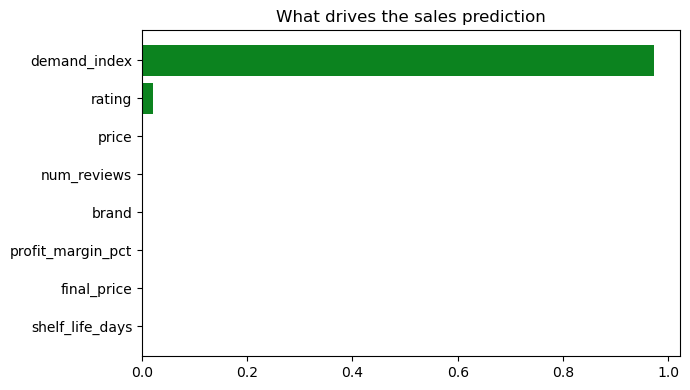

In [14]:
# PLOT 2 — Sales: what the model leans on
imp = sim.sales.feature_importance(8)
plt.figure(figsize=(7, 4))
plt.barh(imp["feature"][::-1], imp["importance"][::-1], color="#0C831F")
plt.title("What drives the sales prediction"); plt.tight_layout(); plt.show()

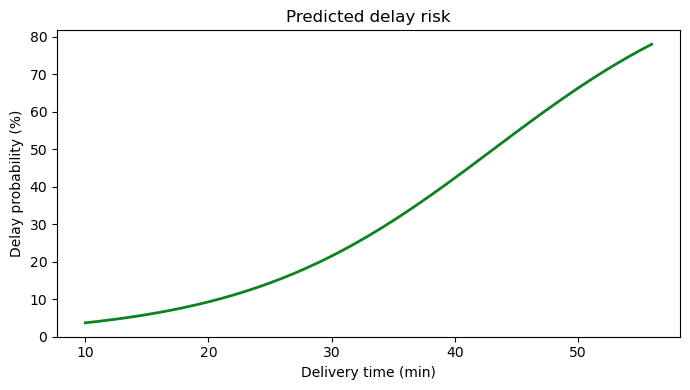

In [15]:
# PLOT 3 — Delivery: delay risk vs delivery time
ts = list(range(10, 57)); ps = [sim.delivery.predict(t) * 100 for t in ts]
plt.figure(figsize=(7, 4)); plt.plot(ts, ps, color="#0C831F", lw=2)
plt.xlabel("Delivery time (min)"); plt.ylabel("Delay probability (%)")
plt.title("Predicted delay risk"); plt.tight_layout(); plt.show()